### ARTI 406 - Assignment 1
# EDA – Air Quality Dataset

**Instructor:** Dr. Alaa Alahmadi


**Student:** Leen Mansour Alqahtani


**ID:** 2230006599


---




### This project aims to analyze and clean the Air Quality dataset using EDA techniques.

### Step 1: Import Libraries

In this step, the required libraries are imported to handle data analysis and visualization.

In [454]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

### Step 2: Load Dataset
The dataset is loaded and the first few rows are displayed to understand its structure.

In [455]:
df = pd.read_csv('AirQualityUCI.csv', sep=';')
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN


### Step 3: Check Dataset Shape
The dataset shape shows the number of rows and columns.

In [456]:
df.shape

(9471, 17)

### Step 4: Check Data Types
This step identifies the data types of each column.

In [457]:
df.dtypes

,0
Date,object
Time,object
CO(GT),object
PT08.S1(CO),float64
NMHC(GT),float64
C6H6(GT),object
PT08.S2(NMHC),float64
NOx(GT),float64
PT08.S3(NOx),float64
NO2(GT),float64


### Step 5: Create Datetime Feature

In this step, the Date and Time columns are combined to create a new Datetime feature.

In [458]:
df['Datetime'] = pd.to_datetime( df['Date'].astype(str) + ' ' + df['Time'].astype(str), format='%d/%m/%Y %H.%M.%S', errors='coerce')

df = df.dropna(subset=['Datetime'])

### Step 6: Handle Missing Values

This step handles missing values to improve data quality and prevent errors during analysis. Missing values can affect results and lead to inaccurate conclusions.

In [459]:
print("Missing values:", df.isna().sum())

Missing values: Date                0
Time                0
CO(GT)              0
PT08.S1(CO)         0
NMHC(GT)            0
C6H6(GT)            0
PT08.S2(NMHC)       0
NOx(GT)             0
PT08.S3(NOx)        0
NO2(GT)             0
PT08.S4(NO2)        0
PT08.S5(O3)         0
T                   0
RH                  0
AH                  0
Unnamed: 15      9357
Unnamed: 16      9357
Datetime            0
dtype: int64


In [460]:
# Fix decimals and convert to numeric
df = df.replace(',', '.', regex=True)

# Convert columns to numeric
for col in df.columns:
    if col not in ['Date', 'Time']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Replace invalid values -200 with NaN
df.replace(-200, np.nan, inplace=True)

# Handle missing/invalid dat
df = df.drop(columns=['Unnamed: 15', 'Unnamed: 16'])
df['Date'] = df['Date'].fillna(method='ffill')
df['Time'] = df['Time'].fillna(method='ffill')

df = df.fillna(df.mean(numeric_only=True))

/tmp/ipykernel_14311/1076226424.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Date'] = df['Date'].fillna(method='ffill')
/tmp/ipykernel_14311/1076226424.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Time'] = df['Time'].fillna(method='ffill')


### Step 7: Remove Duplicates
This step removes duplicate rows from the dataset to ensure accurate and reliable analysis.

In [461]:
df = df.drop_duplicates()

In [462]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


### Dataset after cleaning

Before cleaning, the dataset contained missing values, incorrect formats, and unnecessary columns.

After cleaning:
- Missing values were handled
- Data types were corrected
- Unnecessary columns were removed
- A new Datetime column was created

The dataset became more structured, clean, and ready for analysis.

In [463]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Datetime
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,1078941600000000000
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,1078945200000000000
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,1078948800000000000
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,1078952400000000000
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,1078956000000000000


In [464]:
df.shape

(9357, 16)

In [465]:
print("Missing values:", df.isna().sum())

Missing values: Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
Datetime         0
dtype: int64


In [466]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


### Step 8: Statistical Summary
This step provides statistical measures such as mean, minimum, maximum, and standard deviation.

In [467]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Datetime
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9.357000e+03
mean,2.152750,1099.833166,218.811816,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.025530,1.095782e+18
std,1.316068,212.791672,63.870229,7.302650,261.560236,193.426632,251.743954,43.920954,339.367559,390.612324,8.657639,16.974801,0.395835,9.724599e+15
min,0.100000,647.000000,7.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,1.078942e+18
25%,1.200000,941.000000,218.811816,4.600000,743.000000,112.000000,666.000000,86.000000,1242.000000,742.000000,12.000000,36.600000,0.746100,1.087362e+18
50%,2.152750,1075.000000,218.811816,8.600000,923.000000,229.000000,818.000000,113.091251,1456.264598,983.000000,18.300000,49.234201,1.015400,1.095782e+18
75%,2.600000,1221.000000,218.811816,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200,1.104203e+18
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,1.112623e+18




---


## Exploratory Data Visualization


---



### 1. CO Distribution

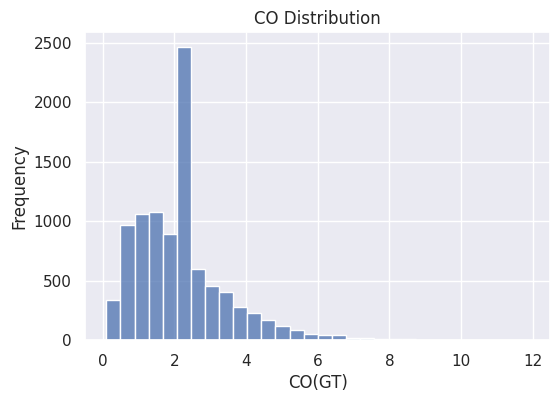

In [468]:
plt.figure(figsize=(6,4))
sns.histplot(df['CO(GT)'], bins=30)

plt.title("CO Distribution")
plt.xlabel("CO(GT)")
plt.ylabel("Frequency")

plt.show()

The distribution of CO levels is right-skewed, where most values are concentrated between 1 and 3.
There are a few higher values extending to the right, which indicates the presence of outliers.
This suggests that high CO levels occur less frequently compared to lower levels.

### 2. Temperature Distribution  

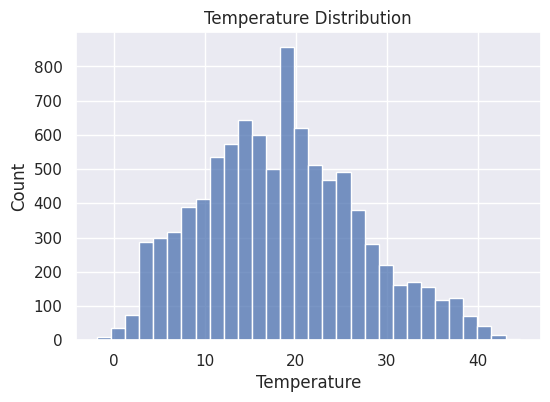

In [469]:
plt.figure(figsize=(6,4))
sns.histplot(df['T'], bins=30)

plt.title("Temperature Distribution")
plt.xlabel("Temperature")

plt.show()

The temperature values are approximately normally distributed, with most values concentrated between 10 and 25 degrees.
The highest frequency appears around the mid-range temperatures, indicating stable conditions.
There are fewer values at very low and very high temperatures.

### 3. Humidity Distribution

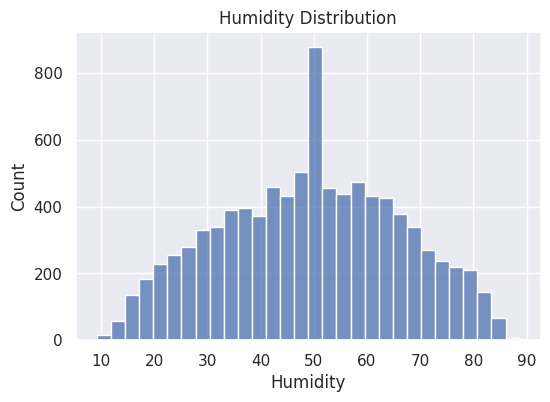

In [470]:
plt.figure(figsize=(6,4))
sns.histplot(df['RH'], bins=30)

plt.title("Humidity Distribution")
plt.xlabel("Humidity")

plt.show()

The humidity values are widely distributed, with most values concentrated between 30 and 70.
The distribution appears roughly symmetric with a peak around the mid-range.
This indicates moderate humidity levels are more common, while very low and very high values are less frequent.

### 4. CO vs Temperature

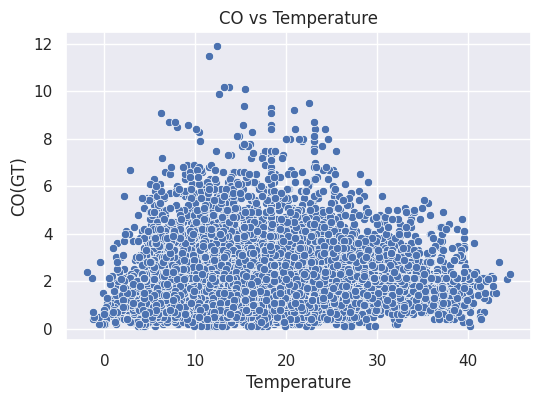

In [471]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['T'], y=df['CO(GT)'])

plt.title("CO vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("CO(GT)")

plt.show()

The scatter plot shows no strong linear relationship between CO levels and temperature.
Most values are scattered across the range, indicating a weak or no correlation.
However, there is a slight tendency for higher CO values to appear at moderate temperatures.

### 5. NO2 vs Temperature  

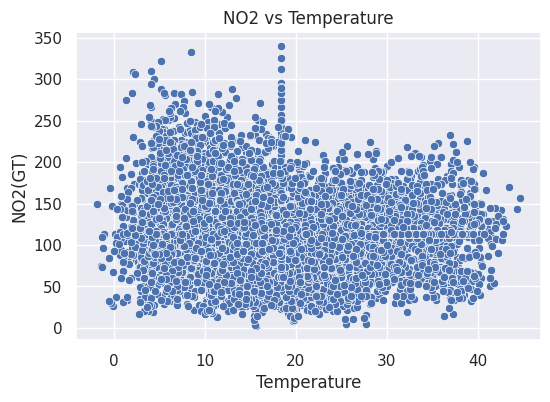

In [472]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['T'], y=df['NO2(GT)'])

plt.title("NO2 vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("NO2(GT)")

plt.show()

The scatter plot shows that NO2 values are widely spread across all temperature levels.
There is no clear linear relationship between NO2 and temperature, indicating a weak correlation.
Most values are concentrated in the mid-range of NO2 regardless of temperature changes.

### 6. CO vs Humidity

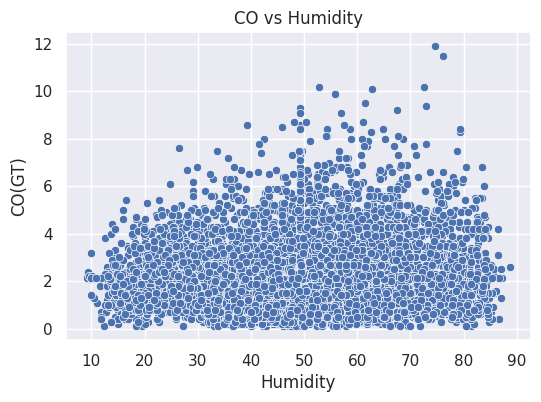

In [473]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['RH'], y=df['CO(GT)'])

plt.title("CO vs Humidity")
plt.xlabel("Humidity")
plt.ylabel("CO(GT)")

plt.show()

The scatter plot shows that CO values are spread across all humidity levels with no clear pattern.
This indicates a weak or no relationship between CO and humidity.
Most values remain low regardless of changes in humidity.

### 7. Temperature vs Humidity

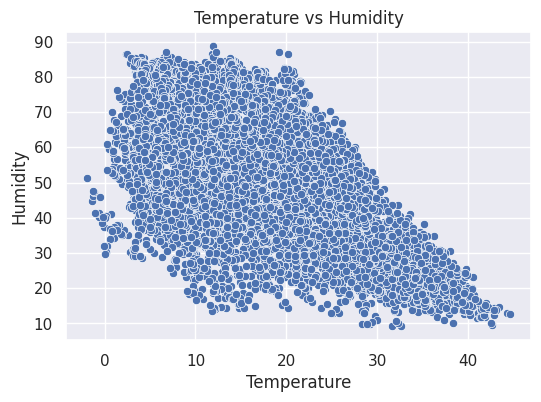

In [474]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['T'], y=df['RH'])

plt.title("Temperature vs Humidity")
plt.xlabel("Temperature")
plt.ylabel("Humidity")

plt.show()

The scatter plot shows a clear negative relationship between temperature and humidity.
As temperature increases, humidity tends to decrease.
This indicates an inverse correlation between the two variables.

### 8. Time Trend

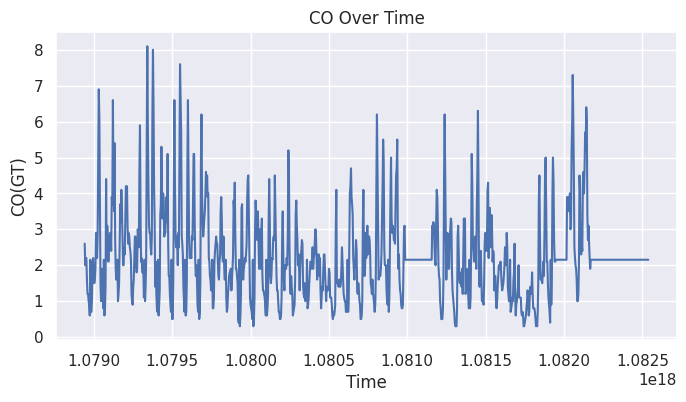

In [475]:
df_sample = df.sort_values('Datetime').head(1000)

plt.figure(figsize=(8,4))
plt.plot(df_sample['Datetime'], df_sample['CO(GT)'])

plt.title("CO Over Time")
plt.xlabel("Time")
plt.ylabel("CO(GT)")

plt.show()

The time series shows that CO levels fluctuate significantly over time with frequent peaks and drops.
There is no clear increasing or decreasing trend, indicating that CO levels vary dynamically.
Some sudden spikes can be observed, suggesting occasional higher pollution levels.

### 9. Correlation Matrix

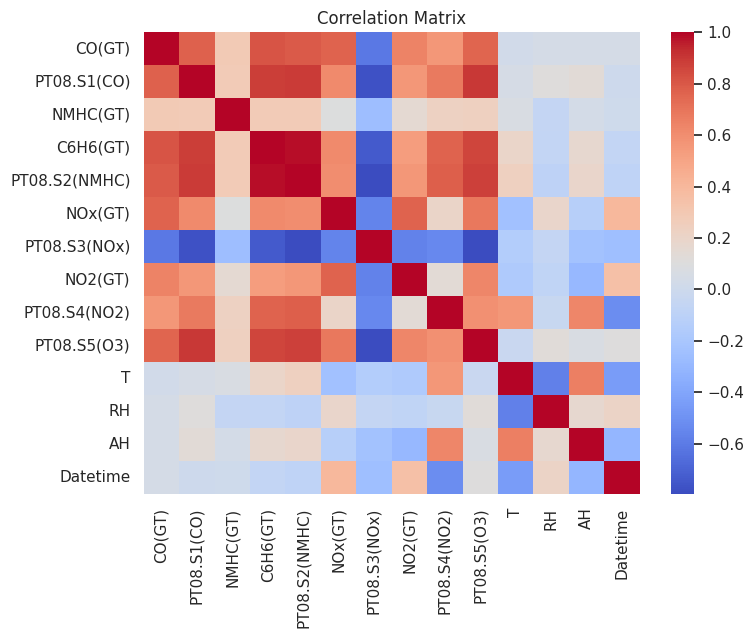

In [476]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

The correlation matrix shows strong positive relationships between several sensor variables, especially between CO and PT08 sensors.
There are also some negative correlations, such as between temperature and humidity.
Overall, this indicates that some features are highly related, while others are independent.